In [1]:
## Enviroment Setup
import os, sys
WORKING_DIR = '/home/dipcik/phdprojects/flame-head-tracker'
os.chdir(WORKING_DIR) # change the working directory to the project's absolute path
print("Current Working Directory: ", os.getcwd())

## Computing Device
device = 'cuda:0'
import torch
torch.cuda.set_device(device)

sys.path.append(WORKING_DIR)
OUTPUT_DIR = WORKING_DIR + '/output_gs'

import matplotlib.pyplot as plt
import numpy as np

from tracker_base_multiview import Tracker


def plot(ret_dict, img_paths=None, save_path=None):
    N = len(ret_dict['img'])

    # figure out which views have renderings
    valid_rows = []
    for i in range(N):
        has_img_rendered = ret_dict['img_rendered'][i] is not None
        has_mesh_rendered = ret_dict['mesh_rendered'][i] is not None
        if has_img_rendered or has_mesh_rendered:
            valid_rows.append(i)

    if not valid_rows:
        print('No valid views to plot.')
        return

    # determine number of columns from first valid row
    cols = 2  # img + img_aligned
    if ret_dict['img_rendered'][valid_rows[0]] is not None: cols += 1
    if ret_dict['mesh_rendered'][valid_rows[0]] is not None: cols += 1

    fig, axes = plt.subplots(len(valid_rows), cols, figsize=(5 * cols, 5 * len(valid_rows)))
    if len(valid_rows) == 1:
        axes = axes[np.newaxis, :]

    col_titles = ['img', 'img_aligned']
    if ret_dict['img_rendered'][valid_rows[0]] is not None: col_titles.append('img_rendered')
    if ret_dict['mesh_rendered'][valid_rows[0]] is not None: col_titles.append('mesh_rendered')

    for row_idx, i in enumerate(valid_rows):
        # row label from image filename
        if img_paths is not None and i < len(img_paths):
            row_label = os.path.basename(img_paths[i])
        else:
            row_label = f'view {i}'

        col = 0
        axes[row_idx, col].imshow(ret_dict['img'][i])
        axes[row_idx, col].set_title(row_label, fontsize=9)
        axes[row_idx, col].axis('off')
        col += 1

        axes[row_idx, col].imshow(ret_dict['img_aligned'][i])
        axes[row_idx, col].set_title('img_aligned')
        axes[row_idx, col].axis('off')
        col += 1

        if ret_dict['img_rendered'][i] is not None:
            axes[row_idx, col].imshow(ret_dict['img_rendered'][i])
            axes[row_idx, col].set_title('img_rendered')
            axes[row_idx, col].axis('off')
            col += 1

        if ret_dict['mesh_rendered'][i] is not None:
            axes[row_idx, col].imshow(ret_dict['mesh_rendered'][i])
            axes[row_idx, col].set_title('mesh_rendered')
            axes[row_idx, col].axis('off')

    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True) if os.path.dirname(save_path) else None
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved plot to {save_path}')
    plt.show()

Current Working Directory:  /home/dipcik/phdprojects/flame-head-tracker


/home/dipcik/miniconda3/envs/tracker/lib/python3.10/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
###########################
## Setup Flame Tracker    #     
###########################

tracker_cfg = {
    'mediapipe_face_landmarker_v2_path': './models/face_landmarker_v2_with_blendshapes.task',
    'flame_model_path': './models/FLAME2020/generic_model.pkl',
    'flame_lmk_embedding_path': './models/landmark_embedding.npy',
    'ear_landmarker_path': './models/ear_landmarker.pth', # optional, remove this line to disable ear landmarks
    'tex_space_path': './models/FLAME_albedo_from_BFM.npz',
    'face_parsing_model_path': './models/79999_iter.pth',
    'template_mesh_file_path': './models/head_template.obj',
    'result_img_size': 512,
    'use_matting': True,           # use image matting to remove background
    'device': device,
}

tracker = Tracker(tracker_cfg)

tracker.update_fov(fov=20)            # optional setting
tracker.set_landmark_detector('mediapipe')  # optional setting

I0000 00:00:1772961522.693891   65568 task_runner.cc:85] GPU suport is not available: INTERNAL: ; RET_CHECK failure (mediapipe/gpu/gl_context_egl.cc:77) display != EGL_NO_DISPLAYeglGetDisplay() returned error 0x3000
W0000 00:00:1772961522.694240   65568 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1772961523.043091   65705 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1772961523.052512   65714 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


creating the FLAME Decoder


/home/dipcik/phdprojects/flame-head-tracker/submodules/flame_lib/FLAME.py:85: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('dynamic_lmk_faces_idx', torch.tensor(lmk_embeddings['dynamic_lmk_faces_idx'], dtype=torch.long))
/home/dipcik/phdprojects/flame-head-tracker/submodules/flame_lib/FLAME.py:86: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('dynamic_lmk_bary_coords', torch.tensor(lmk_embeddings['dynamic_lmk_bary_coords'], dtype=self.dtype))
/home/dipcik/phdprojects/ARTalk_VQVAE/pytorch3d/pytorch3d/io/obj_io.py:551: UserWarning: Mtl file does not exist: ./models/template.mtl
  warnings.warn(f"Mtl file does not exist: {f}")
/home/dipcik/minicond

creating the FLAME Decoder
trained model found. load models/deca_model.tar


/home/dipcik/phdprojects/ARTalk_VQVAE/pytorch3d/pytorch3d/io/obj_io.py:551: UserWarning: Mtl file does not exist: models/template.mtl
  warnings.warn(f"Mtl file does not exist: {f}")
Using cache found in /home/dipcik/.cache/torch/hub/PeterL1n_RobustVideoMatting_master



>>> Flame Head Tracker v4.1-multiview ready.


### NeRSemble Multi-View Reconstruction

### Photometric Fitting

In [3]:
# """
# NeRSemble dataset: 16 camera views, photometric fitting
# """
# img_paths = 
# ret_dict = tracker.load_images_and_run(img_paths, realign=True, photometric_fitting=True)
# plot(ret_dict)

# # check the shapes of returned results
# print('Key             \t Data Type \t Shape')
# print('-----------------------------------------------------------')
# for key in ret_dict:
#     key_str = f'{key}'.ljust(15)
#     if type(ret_dict[key]) is list:
#         sample = ret_dict[key][0]
#         if sample is not None and hasattr(sample, 'shape'):
#             print(f'{key_str} \t list     \t {len(ret_dict[key])}*{sample.shape}')
#         else:
#             print(f'{key_str} \t list     \t {len(ret_dict[key])}')
#     elif hasattr(ret_dict[key], 'shape'):
#         print(f'{key_str} \t np.array \t {ret_dict[key].shape}')

Found 16 views
  cam_220700191_000088.jpg
  cam_221501007_000088.jpg
  cam_222200036_000088.jpg
  cam_222200037_000088.jpg
  cam_222200038_000088.jpg
  cam_222200039_000088.jpg
  cam_222200040_000088.jpg
  cam_222200041_000088.jpg
  cam_222200042_000088.jpg
  cam_222200043_000088.jpg
  cam_222200044_000088.jpg
  cam_222200045_000088.jpg
  cam_222200046_000088.jpg
  cam_222200047_000088.jpg
  cam_222200048_000088.jpg
  cam_222200049_000088.jpg


W0000 00:00:1772961537.451770   65715 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.
/home/dipcik/miniconda3/envs/tracker/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
/home/dipcik/phdprojects/flame-head-tracker/submodules/MICA/models/arcface.py:183: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(self.fp16):
/home/dipcik/miniconda3/envs/tracker/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClas

Saved plot to /home/dipcik/phdprojects/flame-head-tracker/output_gs/multiview_results.png


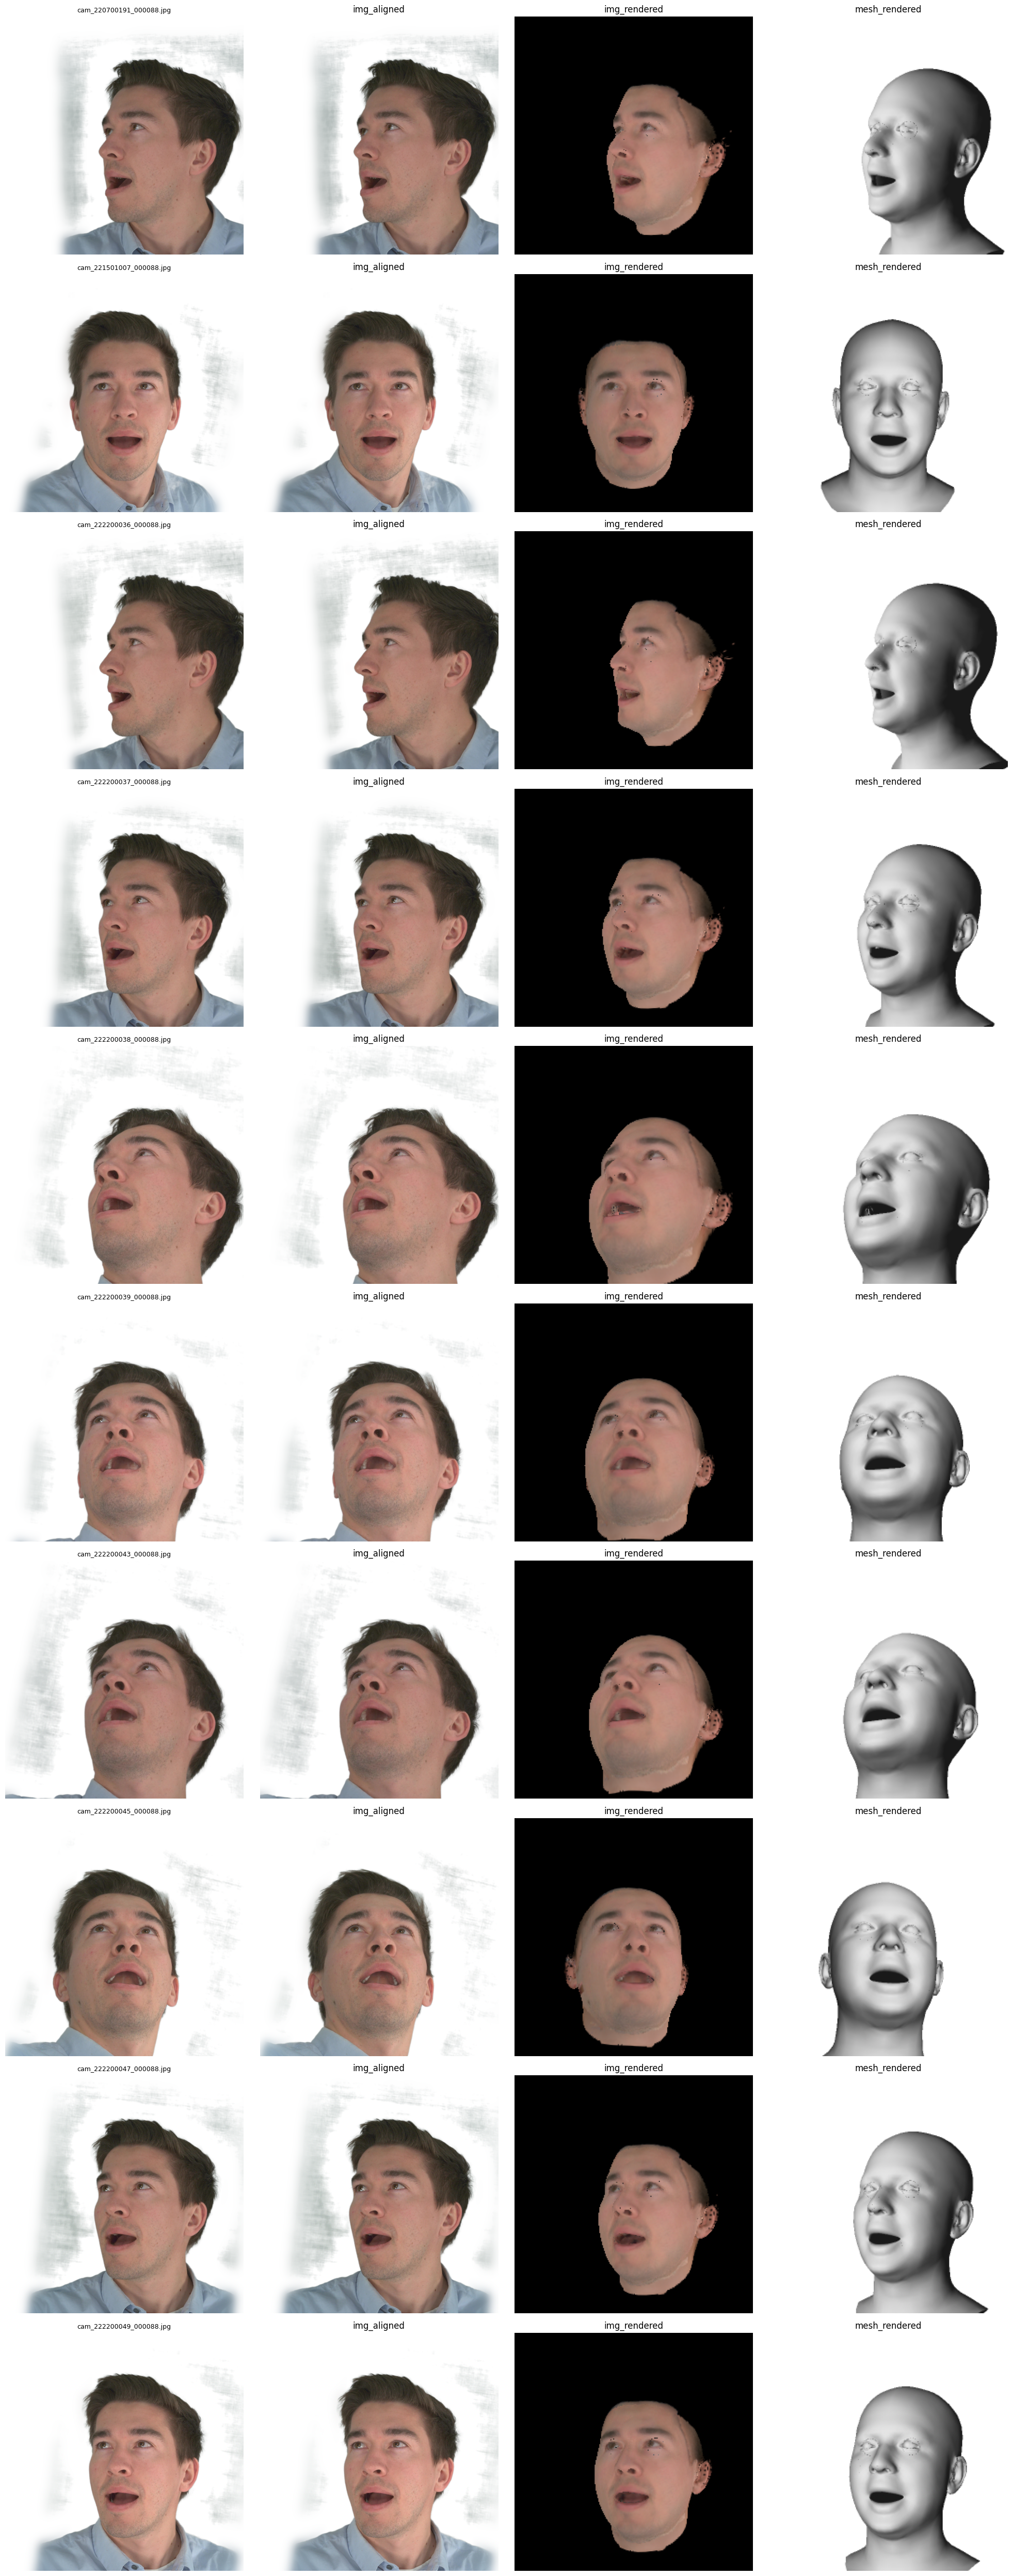

In [4]:
"""
NeRSemble dataset: all 16 camera views, frame 88
"""
import glob

nersemble_img_dir = '/home/dipcik/phdprojects/code-talker-ht/phd-paper-02/codebase/nersemble-data/data/253/sequences/EXP-1-head/images'

img_paths = sorted(glob.glob(f'{nersemble_img_dir}/cam_*_000088.jpg'))
print(f'Found {len(img_paths)} views')
for p in img_paths:
    print(f'  {os.path.basename(p)}')

ret_dict = tracker.load_images_and_run(img_paths, realign=True, photometric_fitting=True)
plot(ret_dict, img_paths=img_paths, save_path=OUTPUT_DIR + '/multiview_results.png')

Saved: flame_regressed.obj, flame_regressed_uv_texture.png
Saved: flame_projected.obj, flame_projected_uv_texture.png


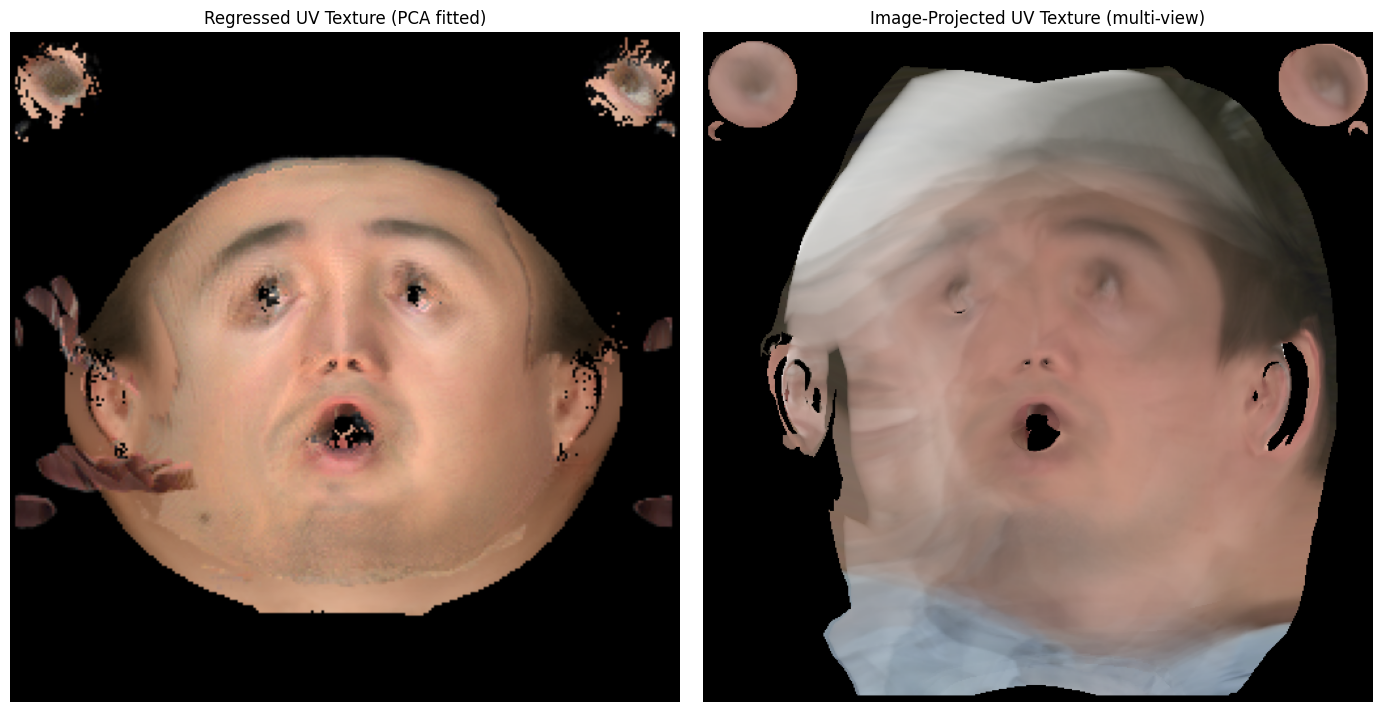

In [5]:
"""
Save regressed FLAME head with UV texture map.
Two options:
  1. save_regressed_head: uses the fitted PCA texture from photometric fitting (clean, smooth)
  2. extract_uv_texture_from_views + save_flame_obj_with_texture: projects real image pixels into UV space (detailed, multi-view blended)
"""

# Option 1: Regressed texture (PCA fitted + displacement map)
tracker.save_regressed_head(ret_dict, output_path='flame_regressed.obj')

# Option 2: Image-projected UV texture from multiple views
uv_texture = tracker.extract_uv_texture_from_views(ret_dict, uv_size=512)
tracker.save_flame_obj_with_texture(ret_dict, uv_texture, output_path='flame_projected.obj')

# Display both UV maps side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Regressed texture
regressed_tex = ret_dict['texture'][0].transpose(1, 2, 0)  # [256,256,3]
regressed_tex = np.clip(regressed_tex * 255, 0, 255).astype(np.uint8)
axes[0].imshow(regressed_tex)
axes[0].set_title('Regressed UV Texture (PCA fitted)')
axes[0].axis('off')

# Image-projected texture
axes[1].imshow(uv_texture)
axes[1].set_title('Image-Projected UV Texture (multi-view)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [6]:
"""
1. FLAME posed mesh (5023 verts, 9976 tris)
2. 100K random points on mesh surface, colored from UV texture
"""
import torch
import numpy as np
import open3d as o3d

shape_params = torch.from_numpy(ret_dict['shape']).float().to(device)
exp_params   = torch.from_numpy(ret_dict['exp']).float().to(device)
jaw_params   = torch.from_numpy(ret_dict['jaw_pose']).float().to(device)
head_params  = torch.from_numpy(ret_dict['head_pose']).float().to(device)
neck_params  = torch.from_numpy(ret_dict['neck_pose']).float().to(device)
eye_params   = torch.from_numpy(ret_dict['eye_pose']).float().to(device)
zero3 = torch.zeros(1, 3, device=device)
zero6 = torch.zeros(1, 6, device=device)

# ── 1. Zero-pose mesh ────────────────────────────────────────────────
verts_zero, _, _ = tracker.flame(
    shape_params=shape_params, expression_params=exp_params,
    head_pose_params=zero3, jaw_pose_params=jaw_params,
    neck_pose_params=zero3, eye_pose_params=zero6,
)
verts_zero_np = verts_zero[0].detach().cpu().numpy()

# ── 2. Posed mesh ────────────────────────────────────────────────────
verts_posed, _, _ = tracker.flame(
    shape_params=shape_params, expression_params=exp_params,
    head_pose_params=head_params, jaw_pose_params=jaw_params,
    neck_pose_params=neck_params, eye_pose_params=eye_params,
)
verts_posed_np = verts_posed[0].detach().cpu().numpy()

# ── 3. UV texture & face data ────────────────────────────────────────
texture_map = ret_dict['texture'][0].transpose(1, 2, 0)  # [256, 256, 3]
texture_map = np.clip(texture_map, 0, 1)
tex_h, tex_w = texture_map.shape[:2]

renderer = tracker.flame_texture_render
faces_idx = renderer.faces[0].cpu().numpy()      # [F, 3]
uvfaces   = renderer.uvfaces[0].cpu().numpy()     # [F, 3]
uvcoords  = renderer.raw_uvcoords[0].cpu().numpy() # [N_uv, 2]
n_faces   = faces_idx.shape[0]

# ── 4. Sample 100K points on mesh surface with UV colors ─────────────
N_SAMPLES = 100_000

# Compute triangle areas for area-weighted sampling
v0 = verts_posed_np[faces_idx[:, 0]]
v1 = verts_posed_np[faces_idx[:, 1]]
v2 = verts_posed_np[faces_idx[:, 2]]
cross = np.cross(v1 - v0, v2 - v0)
areas = 0.5 * np.linalg.norm(cross, axis=1)
probs = areas / areas.sum()

# Sample faces proportional to area
sampled_faces = np.random.choice(n_faces, size=N_SAMPLES, p=probs)

# Random barycentric coordinates
r1 = np.random.rand(N_SAMPLES)
r2 = np.random.rand(N_SAMPLES)
sqrt_r1 = np.sqrt(r1)
bary_a = 1 - sqrt_r1
bary_b = sqrt_r1 * (1 - r2)
bary_c = sqrt_r1 * r2

# 3D positions on mesh surface
p0 = verts_posed_np[faces_idx[sampled_faces, 0]]
p1 = verts_posed_np[faces_idx[sampled_faces, 1]]
p2 = verts_posed_np[faces_idx[sampled_faces, 2]]
points = bary_a[:, None] * p0 + bary_b[:, None] * p1 + bary_c[:, None] * p2

# UV coordinates at sampled points
uv0 = uvcoords[uvfaces[sampled_faces, 0]]
uv1 = uvcoords[uvfaces[sampled_faces, 1]]
uv2 = uvcoords[uvfaces[sampled_faces, 2]]
uv_sampled = bary_a[:, None] * uv0 + bary_b[:, None] * uv1 + bary_c[:, None] * uv2

# Sample colors from UV texture
px = np.clip((uv_sampled[:, 0] * (tex_w - 1)).astype(int), 0, tex_w - 1)
py = np.clip(((1 - uv_sampled[:, 1]) * (tex_h - 1)).astype(int), 0, tex_h - 1)
colors = texture_map[py, px]  # [N_SAMPLES, 3]

# ── 5. Save ──────────────────────────────────────────────────────────
# Posed FLAME mesh
mesh_posed = o3d.geometry.TriangleMesh()
mesh_posed.vertices = o3d.utility.Vector3dVector(verts_posed_np)
mesh_posed.triangles = o3d.utility.Vector3iVector(faces_idx)
mesh_posed.compute_vertex_normals()
o3d.io.write_triangle_mesh('flame_posed.ply', mesh_posed)

# Zero-pose FLAME mesh
mesh_zero = o3d.geometry.TriangleMesh()
mesh_zero.vertices = o3d.utility.Vector3dVector(verts_zero_np)
mesh_zero.triangles = o3d.utility.Vector3iVector(faces_idx)
mesh_zero.compute_vertex_normals()
o3d.io.write_triangle_mesh('flame_zero_pose.ply', mesh_zero)

# 100K colored point cloud
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)
o3d.io.write_point_cloud('flame_posed_100k_points.ply', pcd)

print(f'flame_posed.ply: {len(mesh_posed.vertices)} verts, {len(mesh_posed.triangles)} tris')
print(f'flame_zero_pose.ply: {len(mesh_zero.vertices)} verts, {len(mesh_zero.triangles)} tris')
print(f'flame_posed_100k_points.ply: {len(pcd.points)} points with UV colors')

flame_posed.ply: 5023 verts, 9976 tris
flame_zero_pose.ply: 5023 verts, 9976 tris
flame_posed_100k_points.ply: 100000 points with UV colors
